In [2]:
import pandas as pd

# Load dataset
file_path = "/content/traffic_dataset_with_trend.csv"
df = pd.read_csv(file_path)

# Parse timestamp column
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

# Create extra time features for later charts
df["Hour"] = df["Timestamp"].dt.hour
df["DayOfWeek"] = df["Timestamp"].dt.dayofweek  # 0 = Monday, 6 = Sunday
df["Date"] = df["Timestamp"].dt.date

# Quick preview
df.head()


,Timestamp,Weather,Events,Traffic Volume,Hour,DayOfWeek,Date
0,2023-01-01 00:00:00,Cloudy,False,803.0,0,6,2023-01-01
1,2023-01-01 01:00:00,Clear,False,861.0,1,6,2023-01-01
2,2023-01-01 02:00:00,Clear,False,582.0,2,6,2023-01-01
3,2023-01-01 03:00:00,Cloudy,False,236.0,3,6,2023-01-01
4,2023-01-01 04:00:00,Cloudy,False,569.0,4,6,2023-01-01


In [26]:
import plotly.express as px
!pip install -q kaleido

# Plotly time series
fig = px.line(
    df,
    x="Timestamp",
    y="Traffic Volume",
    title="Hourly Traffic Time Series (Plotly Interactive View)",
    labels={"Timestamp": "Date", "Traffic Volume": "Traffic Volume"},
)

fig.update_layout(
    title_font_size=20,
    template="plotly_white",
    height=500
)

fig.show()






In [6]:
!pip install -U kaleido --quiet


In [22]:
import plotly.express as px

# Interactive Plotly Chart
fig = px.line(
    df,
    x="Timestamp",
    y="Traffic Volume",
    title="Hourly Traffic Time Series (Plotly Interactive View)",
    labels={"Timestamp": "Date", "Traffic Volume": "Traffic Volume"},
)

fig.update_layout(
    title_font_size=20,
    template="plotly_white",
    height=500
)

fig.show()




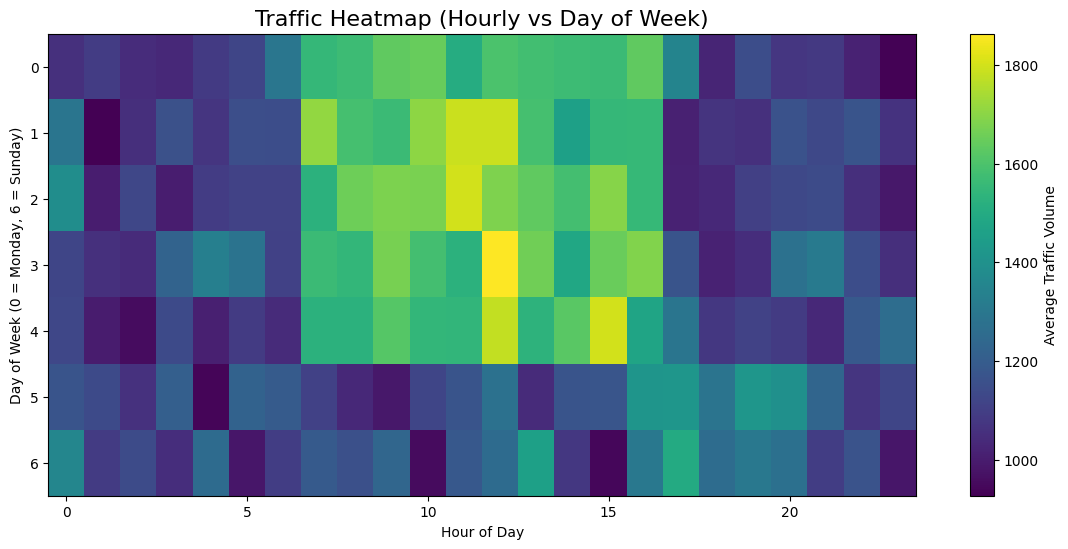

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Prepare heatmap data
heatmap_data = df.pivot_table(
    values="Traffic Volume",
    index="DayOfWeek",    # 0 = Monday, 6 = Sunday
    columns="Hour",
    aggfunc="mean"
)

plt.figure(figsize=(14, 6))
plt.imshow(heatmap_data, aspect='auto', cmap='viridis')

plt.colorbar(label="Average Traffic Volume")
plt.title("Traffic Heatmap (Hourly vs Day of Week)", fontsize=16)
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week (0 = Monday, 6 = Sunday)")

# Save PNG
plt.savefig("/content/traffic_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()




In [20]:
import plotly.express as px

fig = px.scatter(
    df,
    x="Timestamp",
    y="Traffic Volume",
    color="Weather",
    title="Weather Impact on Traffic Volume (Plotly Interactive)",
    labels={"Timestamp": "Date", "Traffic Volume": "Traffic Volume"},
    opacity=0.6
)

fig.update_layout(
    template="plotly_white",
    height=500
)

fig.show()



In [19]:
import plotly.express as px

fig = px.box(
    df,
    x="Events",
    y="Traffic Volume",
    title="Traffic Volume: Event Days vs Non-Event Days (Plotly Interactive)",
    labels={"Events": "Event Happened?", "Traffic Volume": "Traffic Volume"},
    color="Events"
)

fig.update_layout(
    template="plotly_white",
    height=500
)

fig.show()




In [18]:
import plotly.express as px

fig = px.line(
    monthly_avg,
    x=monthly_avg.index,
    y=monthly_avg.values,
    title="Seasonal Traffic Trend (Monthly Averages)",
    labels={"x": "Month", "y": "Average Traffic Volume"}
)

fig.update_layout(
    template="plotly_white",
    height=500
)

fig.show()


